# 03 - Results

Recomputes the headline comparison standalone, renders the diagnostic plots and states verdicts on the project hypotheses.

In [3]:
!pip install -q kaggle numpy pandas scikit-learn matplotlib

import os
from google.colab import userdata

!kaggle datasets download -d gpla77/zum-pro-data      -p /content/data     --unzip
!kaggle datasets download -d gpla77/zum-pro-code      -p /content/src_pkg  --unzip
!kaggle datasets download -d gpla77/zum-pro-models -p /content/models --unzip

import sys, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.metrics import (
    roc_auc_score, roc_curve, brier_score_loss,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, accuracy_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.base import clone

DATA   = Path("/content/data/data")
MODELS = Path("/content/models/dt_models")
SRC    = Path("/content/src_pkg")
sys.path.insert(0, str(SRC))

from src.utils import set_global_seed, HORIZONS
from src import data_loader as dl, preprocessing as pp
set_global_seed()

Dataset URL: https://www.kaggle.com/datasets/gpla77/zum-pro-data
License(s): unknown
100% 27.9k/27.9k [00:00<00:00, 54.2MB/s]

Dataset URL: https://www.kaggle.com/datasets/gpla77/zum-pro-code
License(s): unknown
100% 8.54k/8.54k [00:00<00:00, 21.9MB/s]

Dataset URL: https://www.kaggle.com/datasets/gpla77/zum-pro-models
License(s): unknown
100% 12.6k/12.6k [00:00<00:00, 26.3MB/s]



In [4]:
train, test, submission, meta = dl.load_raw(folder=DATA)
features     = json.load(open(MODELS / "feature_names.json"))
best_params  = json.load(open(MODELS / "best_params.json"))

fitted = {h: joblib.load(MODELS / f"dt_{h}h.joblib") for h in HORIZONS}

from src.preprocessing import engineer_features
eng_names = list(engineer_features(train[features].head(1), use_interactions=True).columns)

print(f"Train: {train.shape} | features: {len(features)} | engineered: {len(eng_names)}")
for h in HORIZONS:
    p = fitted[h].named_steps["model"].get_params()
    print(f"  {h}h -> max_depth={p['max_depth']}, min_samples_leaf={p['min_samples_leaf']}")

Train: (221, 37) | features: 34 | engineered: 41
  12h -> max_depth=3, min_samples_leaf=10
  24h -> max_depth=3, min_samples_leaf=10
  48h -> max_depth=3, min_samples_leaf=10
  72h -> max_depth=3, min_samples_leaf=1


## 03 – Decision Tree Analysis

The Decision Tree was selected as the final model due to strong cross-validated
performance and full interpretability — every prediction can be traced from root
to leaf without approximation. Gradient Boosting achieved a marginally higher
Hybrid Score but provides no equivalent transparency.

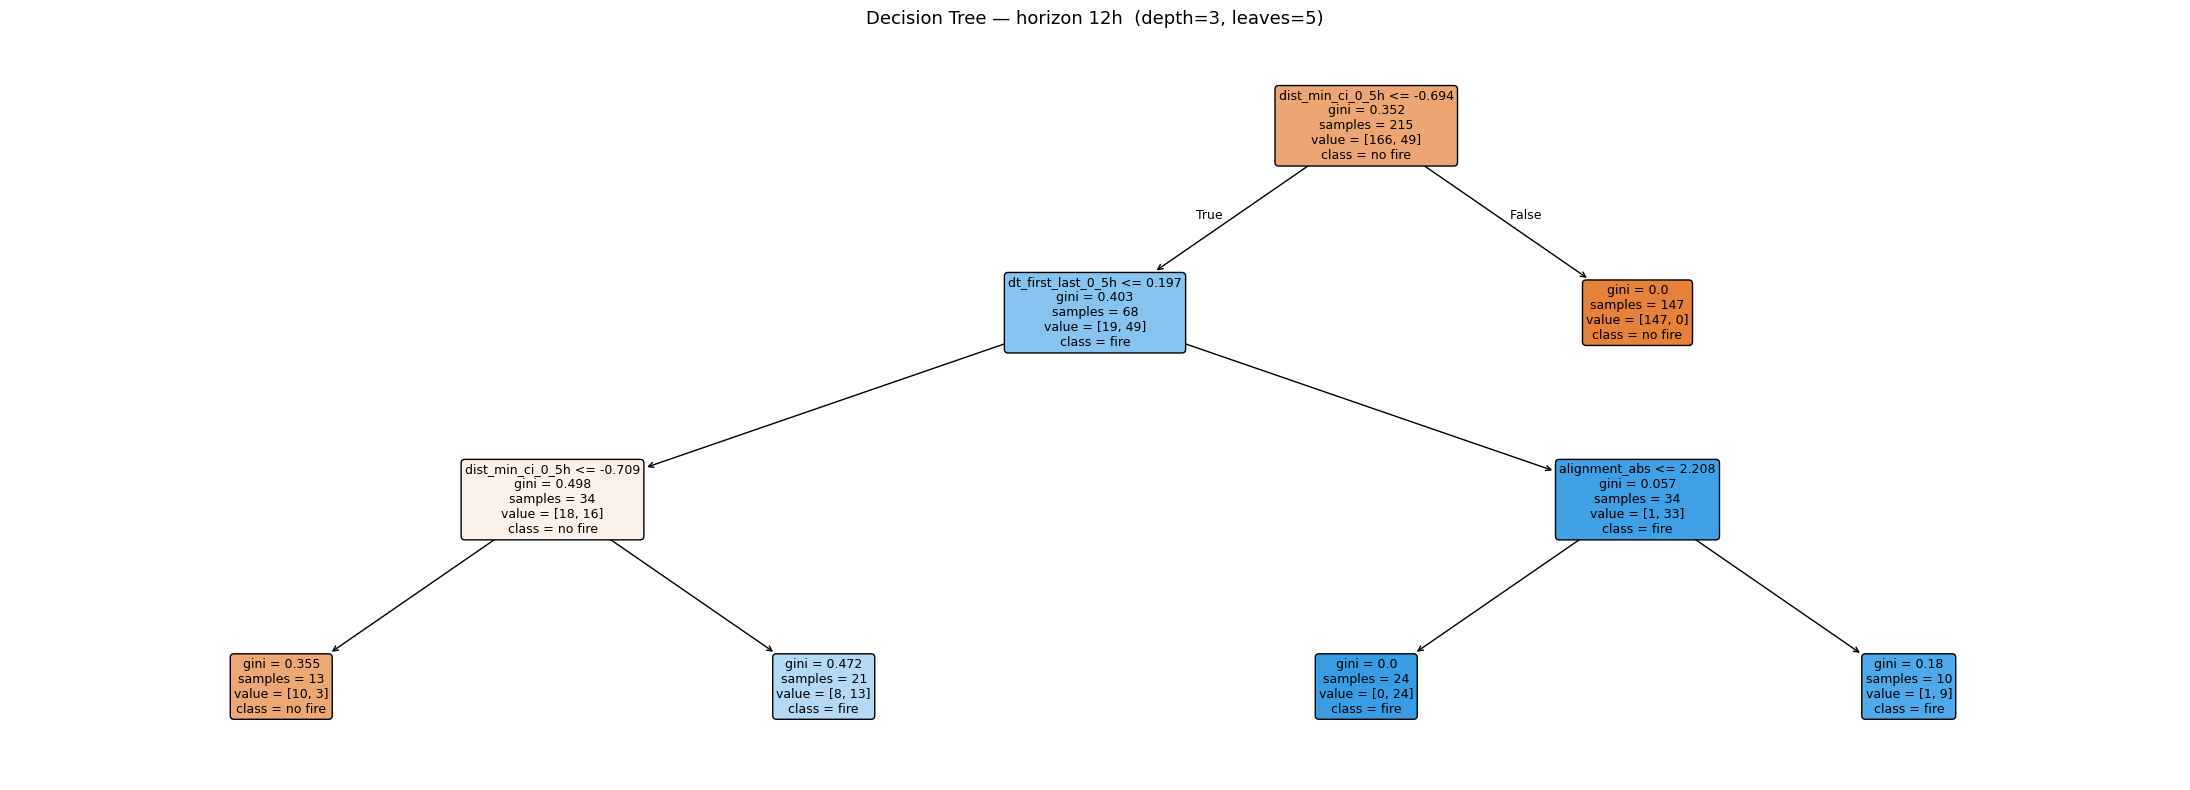

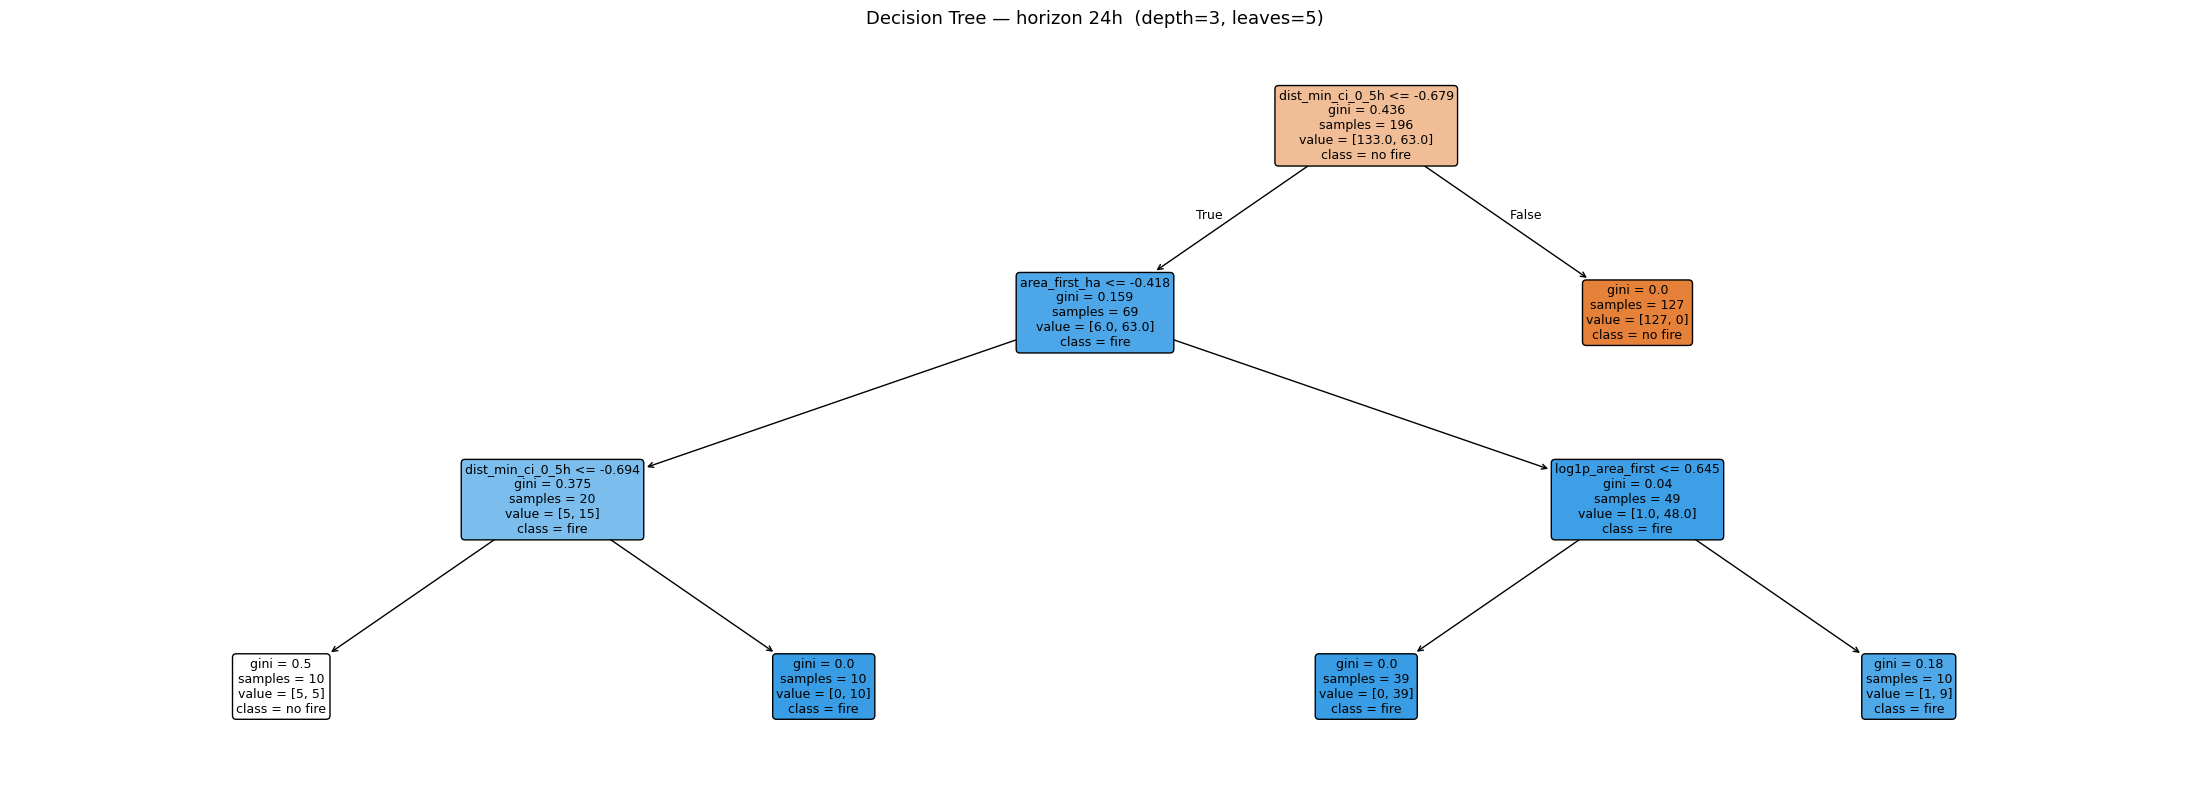

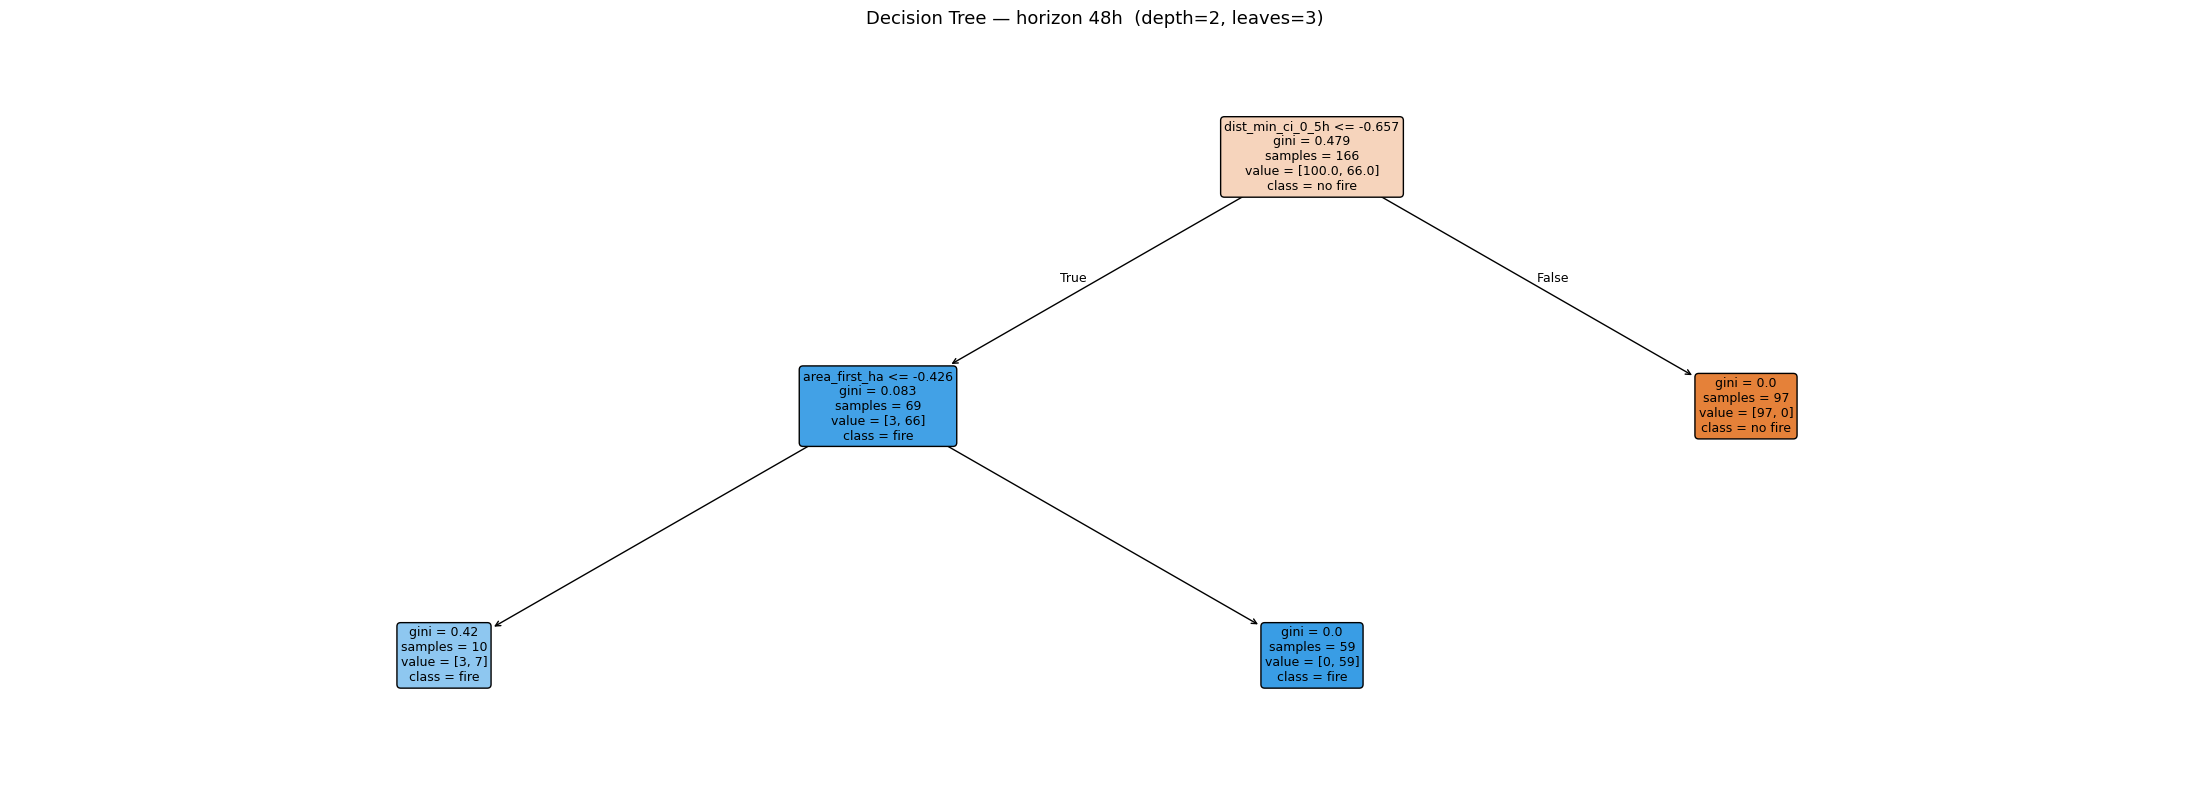

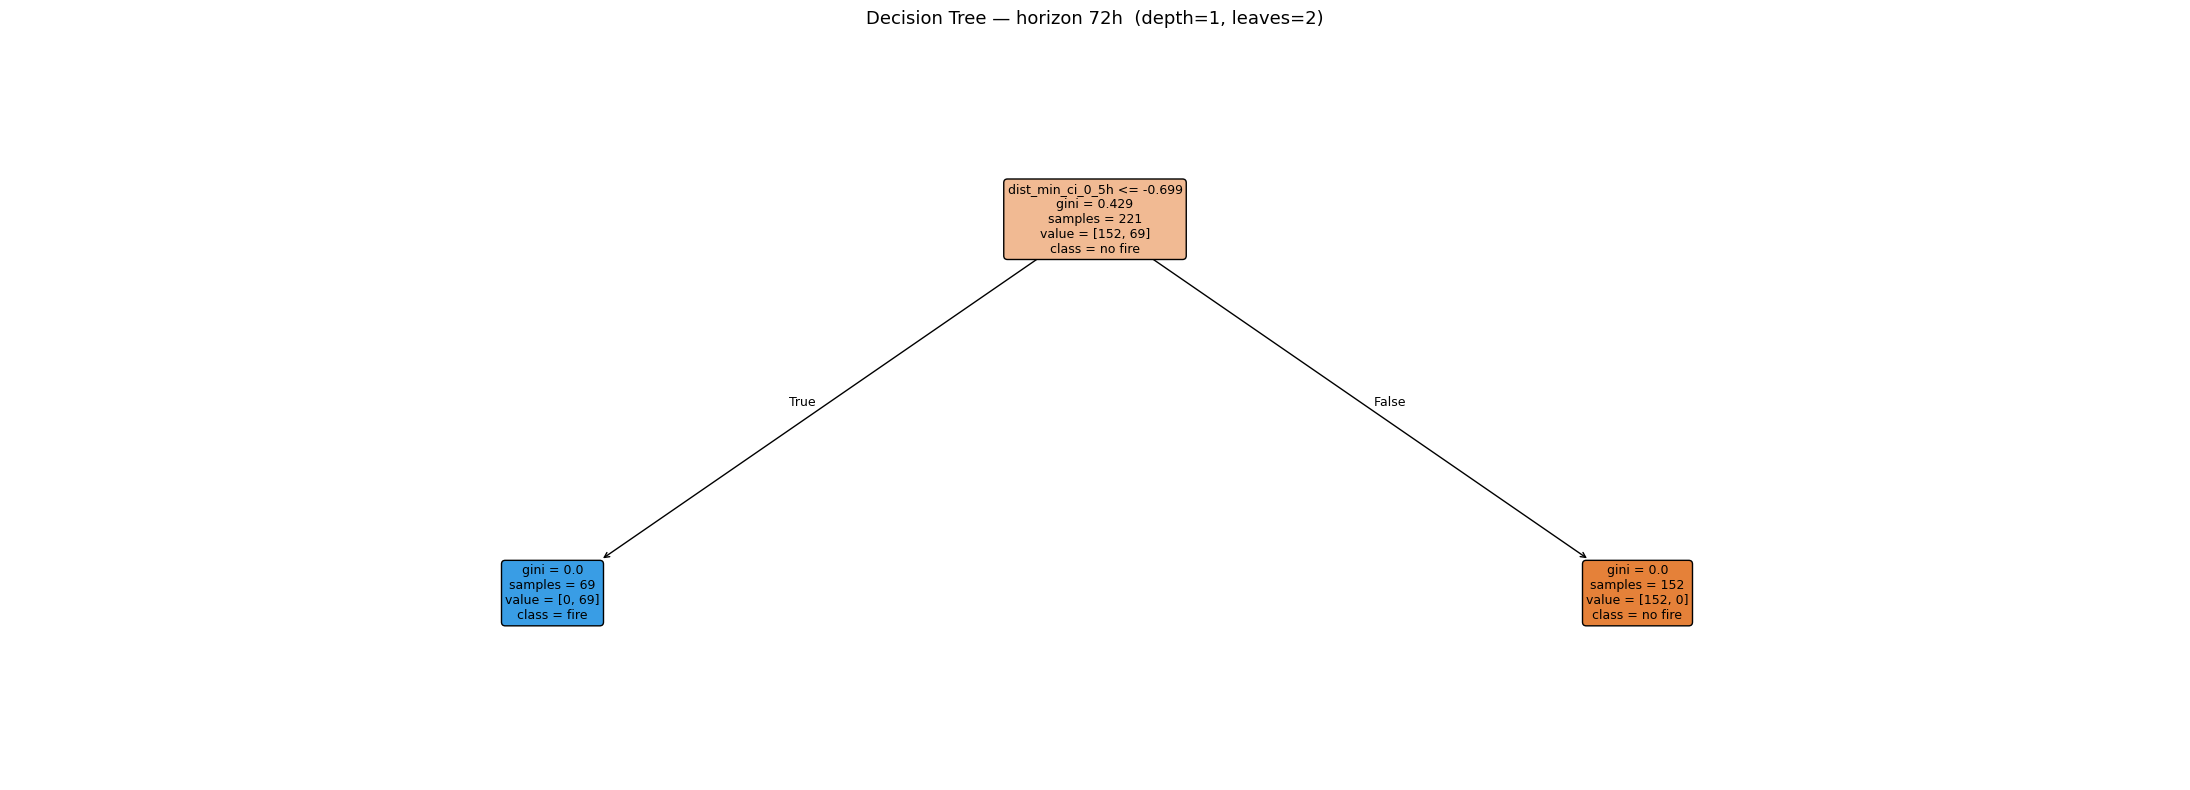

In [5]:
for h in HORIZONS:
    model = fitted[h].named_steps["model"]
    fig, ax = plt.subplots(figsize=(22, 8))
    plot_tree(
        model,
        feature_names=eng_names,
        class_names=["no fire", "fire"],
        filled=True,
        rounded=True,
        fontsize=9,
        ax=ax,
    )
    ax.set_title(
        f"Decision Tree — horizon {h}h  "
        f"(depth={model.get_depth()}, leaves={model.get_n_leaves()})",
        fontsize=13
    )
    plt.tight_layout()
    plt.savefig(f"/content/dt_tree_{h}h.png", dpi=150, bbox_inches="tight")
    plt.show()

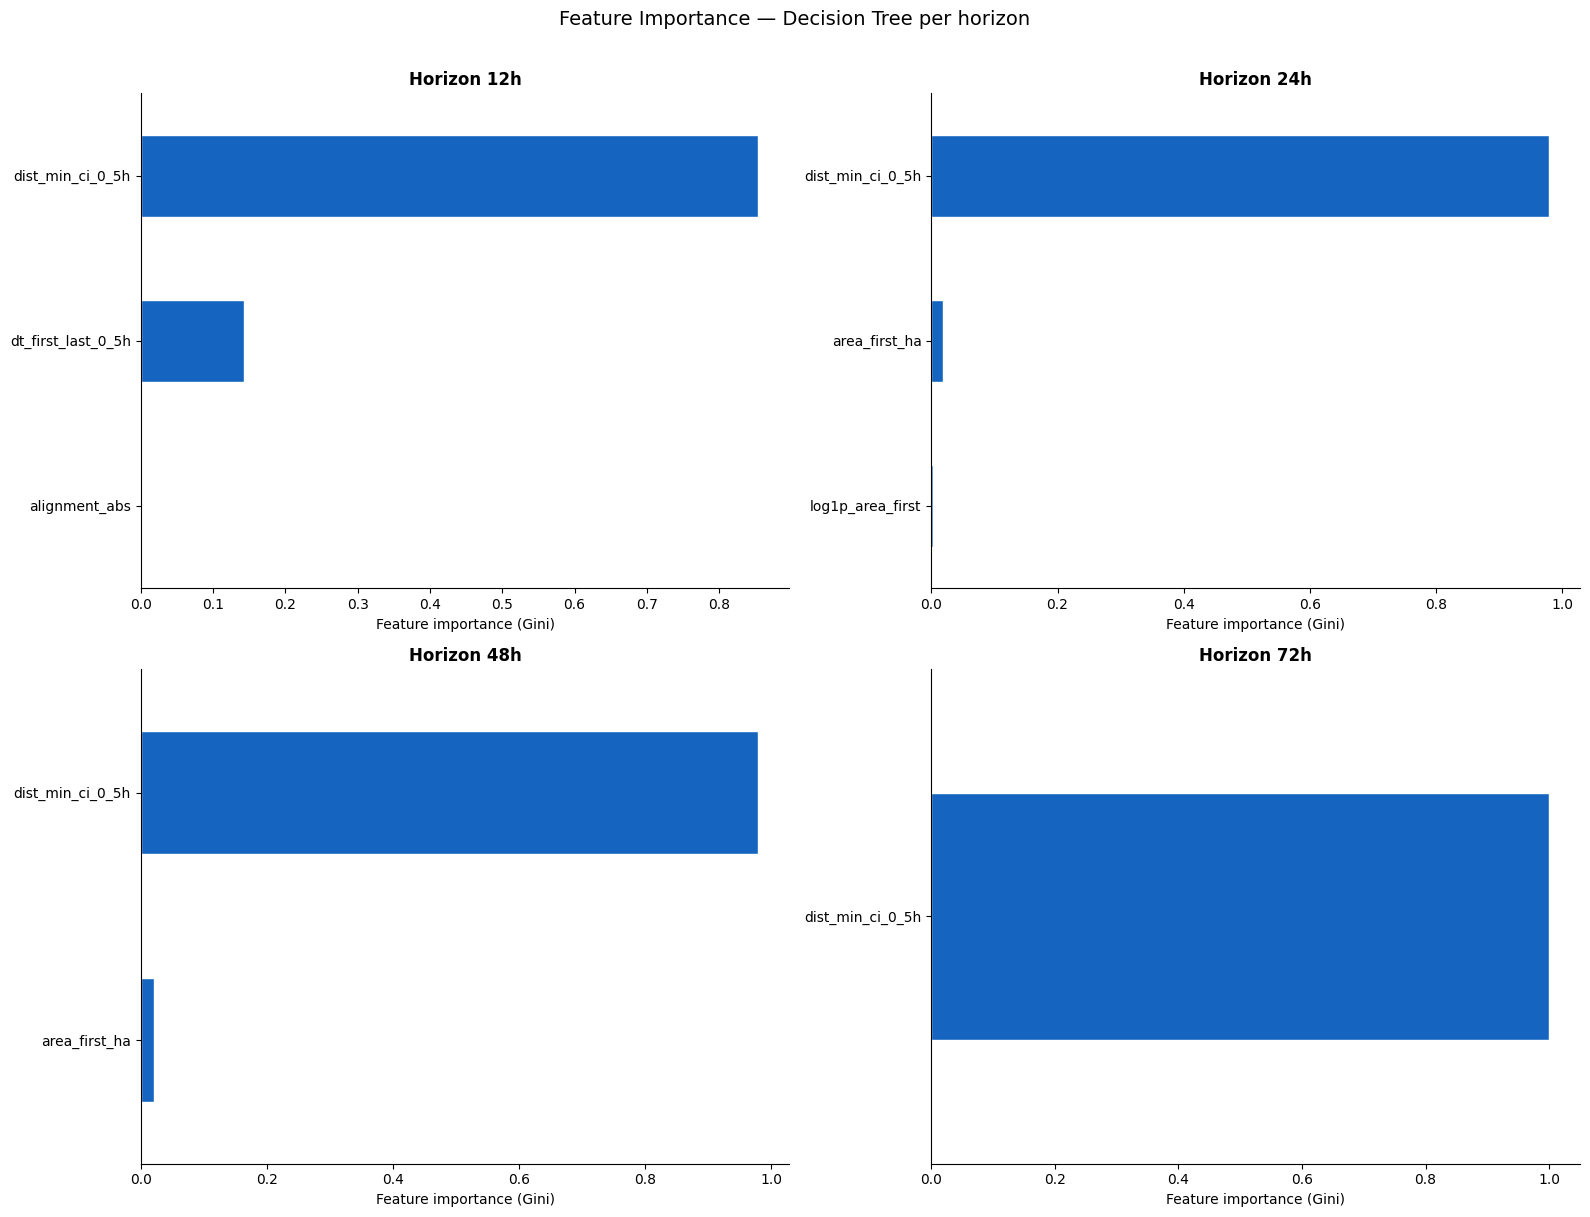

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, h in enumerate(HORIZONS):
    model = fitted[h].named_steps["model"]
    imp = pd.Series(model.feature_importances_, index=eng_names)
    imp = imp[imp > 0].sort_values()

    ax = axes[idx]
    imp.plot(kind="barh", ax=ax, color="#1565C0", edgecolor="white")
    ax.set_title(f"Horizon {h}h", fontsize=12, fontweight="bold")
    ax.set_xlabel("Feature importance (Gini)")
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

fig.suptitle("Feature Importance — Decision Tree per horizon", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("/content/dt_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
N_SPLITS = 5
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

oof = {}
rows = []

for h in HORIZONS:
    usable, y_arr = dl.horizon_labels(train, h)
    X = train.loc[usable, features].reset_index(drop=True)
    y = pd.Series(y_arr[usable]).reset_index(drop=True)

    base_model = fitted[h].named_steps["model"]
    pipe = Pipeline([
        ("pre",   pp.build_preprocessor(use_interactions=True, scale=True)),
        ("model", clone(base_model)),
    ])

    prob = cross_val_predict(pipe, X, y, cv=cv, method="predict_proba")[:, 1]
    pred = (prob >= 0.5).astype(int)

    oof[h] = {"y_true": y.to_numpy(), "prob": prob, "pred": pred}

    tn, fp, fn, tp = confusion_matrix(y, pred).ravel()
    rows.append({
        "Horizon":     f"{h}h",
        "ROC-AUC":     round(roc_auc_score(y, prob), 4),
        "Brier":       round(brier_score_loss(y, prob), 4),
        "F1":          round(f1_score(y, pred, zero_division=0), 4),
        "Accuracy":    round(accuracy_score(y, pred), 4),
        "Sensitivity": round(tp / (tp + fn) if (tp + fn) else 0, 4),
        "Specificity": round(tn / (tn + fp) if (tn + fp) else 0, 4),
        "N (usable)":  int(usable.sum()),
        "Positives":   int(y.sum()),
    })

metrics_df = pd.DataFrame(rows).set_index("Horizon")
metrics_df

,ROC-AUC,Brier,F1,Accuracy,Sensitivity,Specificity,N (usable),Positives
Horizon,,,,,,,,
12h,0.9645,0.0702,0.7723,0.8930,0.7959,0.9217,215,49
24h,0.9819,0.0301,0.9545,0.9694,1.0000,0.9549,196,63
48h,0.9963,0.0173,0.9778,0.9819,1.0000,0.9700,166,66
72h,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,221,69


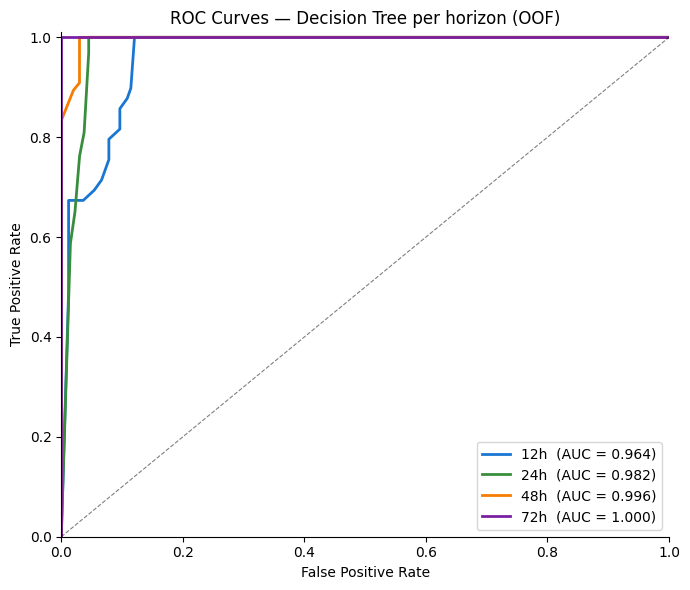

In [8]:
colors = ["#1976D2", "#388E3C", "#F57C00", "#7B1FA2"]

fig, ax = plt.subplots(figsize=(7, 6))
for idx, h in enumerate(HORIZONS):
    fpr, tpr, _ = roc_curve(oof[h]["y_true"], oof[h]["prob"])
    auc = roc_auc_score(oof[h]["y_true"], oof[h]["prob"])
    ax.plot(fpr, tpr, color=colors[idx], lw=2, label=f"{h}h  (AUC = {auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.5)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Decision Tree per horizon (OOF)")
ax.legend()
ax.set_xlim(0, 1); ax.set_ylim(0, 1.01)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig("/content/dt_roc.png", dpi=150, bbox_inches="tight")
plt.show()

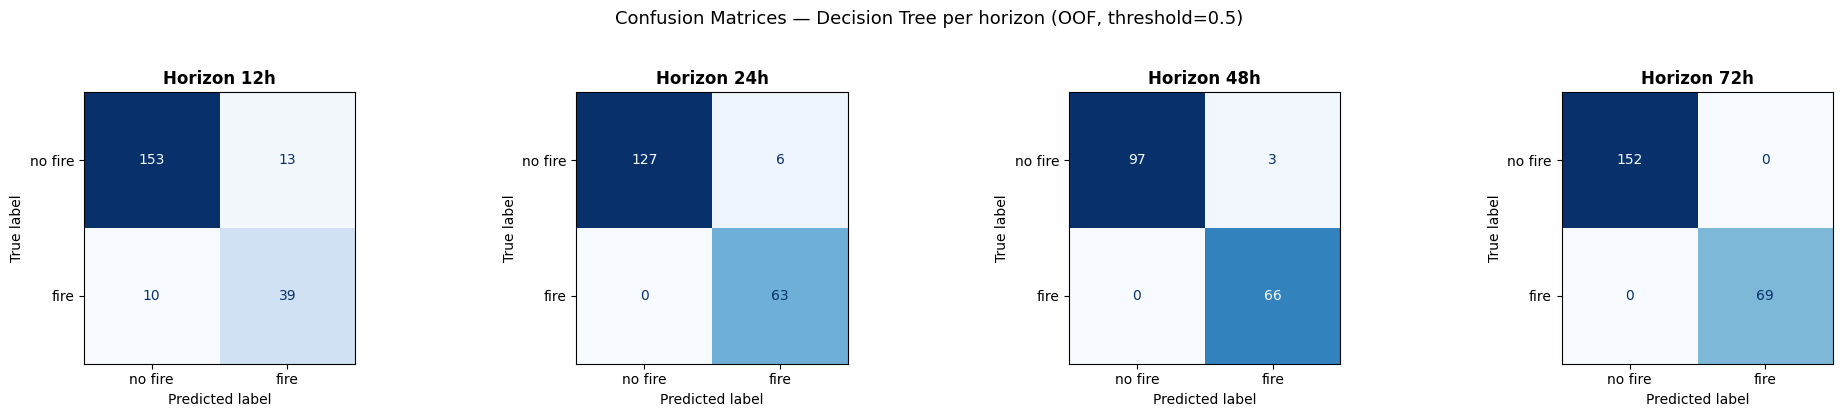

In [9]:
fig, axes = plt.subplots(1, len(HORIZONS), figsize=(5 * len(HORIZONS), 4))

for ax, h in zip(axes, HORIZONS):
    cm = confusion_matrix(oof[h]["y_true"], oof[h]["pred"])
    ConfusionMatrixDisplay(cm, display_labels=["no fire", "fire"]).plot(
        ax=ax, colorbar=False, cmap="Blues"
    )
    ax.set_title(f"Horizon {h}h", fontsize=12, fontweight="bold")

fig.suptitle("Confusion Matrices — Decision Tree per horizon (OOF, threshold=0.5)",
             fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig("/content/dt_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

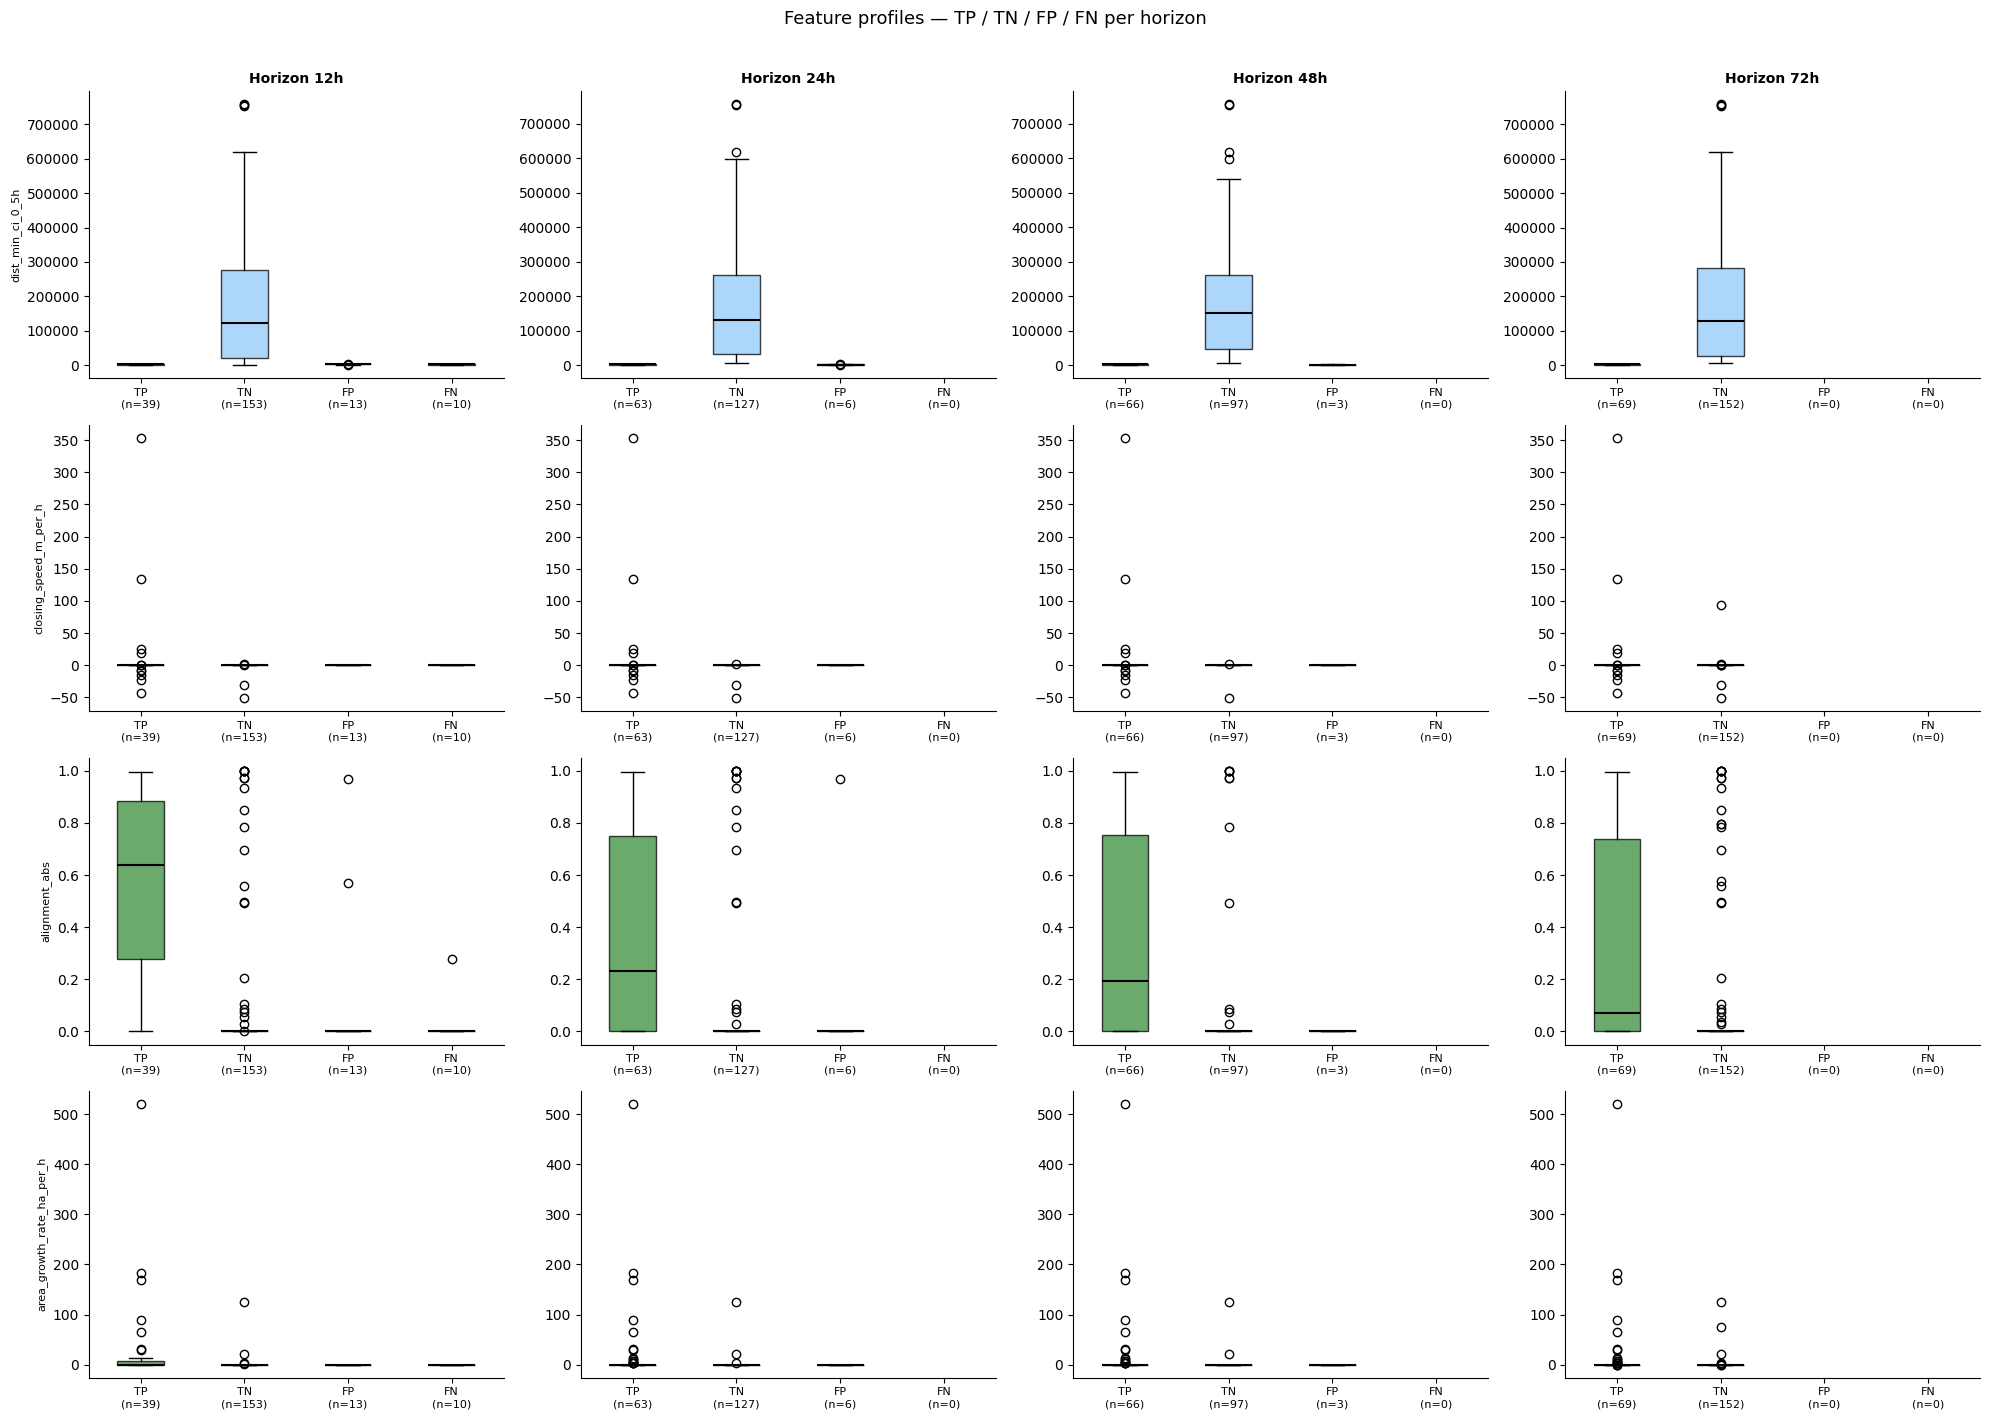

In [10]:
KEY = [f for f in [
    "dist_min_ci_0_5h", "closing_speed_m_per_h",
    "alignment_abs", "area_growth_rate_ha_per_h"
] if f in features]

fig, axes = plt.subplots(len(KEY), len(HORIZONS),
                         figsize=(5 * len(HORIZONS), 3.5 * len(KEY)))

GROUP_COLORS = {"TP": "#388E3C", "TN": "#90CAF9", "FP": "#F57C00", "FN": "#C62828"}

for col, h in enumerate(HORIZONS):
    usable, _ = dl.horizon_labels(train, h)
    idx = np.where(usable)[0]
    y_t, pr, pd_ = oof[h]["y_true"], oof[h]["prob"], oof[h]["pred"]

    masks = {
        "TP": (pd_ == 1) & (y_t == 1),
        "TN": (pd_ == 0) & (y_t == 0),
        "FP": (pd_ == 1) & (y_t == 0),
        "FN": (pd_ == 0) & (y_t == 1),
    }

    for row, feat in enumerate(KEY):
        ax = axes[row][col] if len(KEY) > 1 else axes[col]
        vals = train.iloc[idx][feat].to_numpy()
        data = [vals[m] for m in masks.values()]
        counts = [m.sum() for m in masks.values()]

        bp = ax.boxplot(data, patch_artist=True,
                        medianprops=dict(color="black", linewidth=1.5))
        for patch, label in zip(bp["boxes"], GROUP_COLORS):
            patch.set_facecolor(GROUP_COLORS[label])
            patch.set_alpha(0.75)

        ax.set_xticks(range(1, 5))
        ax.set_xticklabels(
            [f"{l}\n(n={c})" for l, c in zip(masks.keys(), counts)], fontsize=8
        )
        if col == 0:
            ax.set_ylabel(feat, fontsize=8)
        if row == 0:
            ax.set_title(f"Horizon {h}h", fontsize=10, fontweight="bold")
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

fig.suptitle("Feature profiles — TP / TN / FP / FN per horizon", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("/content/dt_error_profile.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
print("=" * 50)
print("  Decision Tree — OOF metrics per horizon")
print("=" * 50)
display(metrics_df)

print("\nTop feature per horizon:")
for h in HORIZONS:
    imp = pd.Series(
        fitted[h].named_steps["model"].feature_importances_, index=eng_names
    )
    top = imp.idxmax()
    print(f"  {h}h  ->  {top}  ({imp[top]:.3f})")

  Decision Tree — OOF metrics per horizon


,ROC-AUC,Brier,F1,Accuracy,Sensitivity,Specificity,N (usable),Positives
Horizon,,,,,,,,
12h,0.9645,0.0702,0.7723,0.8930,0.7959,0.9217,215,49
24h,0.9819,0.0301,0.9545,0.9694,1.0000,0.9549,196,63
48h,0.9963,0.0173,0.9778,0.9819,1.0000,0.9700,166,66
72h,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,221,69



Top feature per horizon:
  12h  ->  dist_min_ci_0_5h  (0.854)
  24h  ->  dist_min_ci_0_5h  (0.979)
  48h  ->  dist_min_ci_0_5h  (0.980)
  72h  ->  dist_min_ci_0_5h  (1.000)
